# Instalar ollama

In [2]:
!pkill ollama || true
!curl -fsSL https://ollama.com/install.sh | OLLAMA_VERSION=0.7.1 sh
!sleep 2
!nohup /usr/local/bin/ollama serve > /dev/null 2>&1 &
!sleep 3
!ollama --version

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tgz
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
ollama version is 0.7.1


In [3]:
!pkill ollama || true
!sleep 2
!nohup /usr/local/bin/ollama serve > /dev/null 2>&1 &
!sleep 3
!ollama --version

ollama version is 0.7.1


In [4]:
import importlib.util
import torch

## Instalar una terminal externa, para ejecutar ollama desde colab

In [5]:
!pip install colab-xterm
%load_ext colabxterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 4.8 MB/s eta 0:00:00


Despues de ejecutar la siguiente celda (%xterm), se debe ejecutar dentro ***ollama serve &***

In [6]:
%xterm # Ejecutar esta celda pero no escribir nada dentro de la terminal.

Launching Xterm...

<IPython.core.display.Javascript object>

In [7]:
!ollama pull llama3.2-vision

In [8]:
!pip install ollama

# Uso del modelo

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
#Cargamos el dataframe con las descripciones mnauales y los prompts:
import pandas as pd

df =pd.read_excel("descriptions.xlsx")
df["file_name"] = df["file_name"].str.replace('"', '')
df.head()

,file_name,manual_description_1,manual_description_2,manual_description_3,prompt_1,prompt_2,prompt_3
0,01.jpg,"""A close-up shot of a Chilean 500 pesos coin f...","""A macro photograph focusing on a Chilean 500 ...","""A high-detail macro shot where a Chilean 500-...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
1,02.jpg,"""A straight railway track stretching into the ...","""A ground-level perspective of a single railwa...","""A centered, wide-angle shot looking down a st...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
2,03.jpg,"""A close-up shot of an elderly person's wrinkl...","""A macro photograph focusing on the textured s...","""An intimate close-up capturing the weathered ...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
3,04.jpg,"""A wide shot of a vibrant golden sunset over t...","""A landscape photograph capturing a sunset ove...","""A stunning backlit seascape capturing the eph...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
4,05.jpg,"""A field filled with bright yellow wildflower ...","""A medium-wide shot capturing a dense patch of...","""A vibrant landscape photograph showcasing a d...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...


In [10]:
# Definimos una funcion auxiliar para hacer los captions:

import ollama

def generate_caption_llama(image_path, prompt_text):

    response = ollama.chat(
        model='llama3.2-vision',
        messages=[
            {
                'role': 'user',
                'content': prompt_text,
                'images': [image_path]
            }
        ]
    )

    caption = response['message']['content'].strip()

    return caption

#Probamos con una imagen:

import os
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"

row = df.iloc[17]

image_path = os.path.join(IMAGE_DIR, row["file_name"])
caption = generate_caption_llama(image_path, row["prompt_3"])

print(caption)


The image depicts a small owl standing in a field of grass, showcasing its distinctive features and surroundings.

* **Owl**
	+ The owl is positioned centrally in the image, facing left.
	+ It has a brown and white spotted plumage, with a white underside and a brown back.
	+ Its yellow eyes are prominent, with a black pupil and a white ring around the iris.
	+ The owl's beak is short and yellow, and its legs are not visible.
* **Grass**
	+ The grass surrounding the owl is dry and brown, with some green blades visible.
	+ The grass is not particularly tall, but it is long enough to cover the owl's feet.
	+ The grass appears to be growing in a field or meadow, with no visible trees or other vegetation.
* **Lighting**
	+ The lighting in the image is soft and natural, with no harsh shadows or highlights.
	+ The sun appears to be shining from the left side of the image, casting a warm glow over the scene.
	+ The lighting is not particularly dramatic, but it adds depth and interest to the im

In [ ]:
#Creamos estas 3 columnas nuevas con las descripciones generadas por el modelo en base a cada prompt:

for col in ["llama_prompt1", "llama_prompt2", "llama_prompt3"]:
    if col not in df.columns:
        df[col] = ""

In [ ]:
# Iteramos sobre las 20 imagenes:

import os

for idx, row in df.iterrows():

    try:

        image_path = os.path.join(IMAGE_DIR,row["file_name"])
        print(f"[{idx+1}/{len(df)}] Procesando {row['file_name']}")
        df.loc[idx, "llama_prompt3"] = generate_caption_llama(image_path,row["prompt_3"])


        # Guardado de seguridad
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/resultados_llama3.xlsx", index=False)

        print("Completado")

    except Exception as e:

        print(f" Error en {row['file_name']}: {e}")

        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/resultados_llama3.xlsx", index=False)


[1/19] Procesando 01.jpg
Completado
[2/19] Procesando 02.jpg
Completado
[3/19] Procesando 03.jpg
Completado
[4/19] Procesando 04.jpg
Completado
[5/19] Procesando 05.jpg
Completado
[6/19] Procesando 06.jpg


KeyboardInterrupt: 

el modelo se demora aproximadamente 16,84 segundos en procesar una imagen

In [ ]:
df2 = pd.read_excel("/content/resultados_llama final.xlsx")
df2.head()

,file_name,manual_description_1,manual_description_2,manual_description_3,prompt_1,prompt_2,prompt_3,llama_prompt1,llama_prompt2,llama_prompt3
0,01.jpg,"""A close-up shot of a Chilean 500 pesos coin f...","""A macro photograph focusing on a Chilean 500 ...","""A high-detail macro shot where a Chilean 500-...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...","""Perform an exhaustive and highly detailed ana...",The image shows a close-up of a Mexican 500-pe...,This image presents a close-up view of a Mexic...,"The image presents a close-up view of a coin, ..."
1,02.jpg,"""A straight railway track stretching into the ...","""A ground-level perspective of a single railwa...","""A centered, wide-angle shot looking down a st...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...","""Perform an exhaustive and highly detailed ana...",The image depicts a desolate landscape with a ...,This image features a pair of railway tracks s...,"The image depicts a vast, arid landscape with ..."
2,03.jpg,"""A close-up shot of an elderly person's wrinkl...","""A macro photograph focusing on the textured s...","""An intimate close-up capturing the weathered ...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...","""Perform an exhaustive and highly detailed ana...",The image shows a close-up of an older woman's...,This image captures a close-up view of an olde...,The image presents a close-up view of an elder...
3,04.jpg,"""A wide shot of a vibrant golden sunset over t...","""A landscape photograph capturing a sunset ove...","""A stunning backlit seascape capturing the eph...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...","""Perform an exhaustive and highly detailed ana...","The image shows a sunset over the ocean, with ...",The image captures a serene sunset over the oc...,The image captures a serene sunset over the oc...
4,05.jpg,"""A field filled with bright yellow wildflower ...","""A medium-wide shot capturing a dense patch of...","""A vibrant landscape photograph showcasing a d...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...","""Perform an exhaustive and highly detailed ana...",The image features a field of vibrant yellow f...,This photograph features a vibrant field of ye...,The image presents a vast expanse of yellow fl...


In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

from sklearn.metrics.pairwise import cosine_similarity

def semantic_similarity(text1, text2):

    emb1 = embedding_model.encode(text1,convert_to_numpy=True)
    emb2 = embedding_model.encode(text2,convert_to_numpy=True)

    return cosine_similarity([emb1],[emb2])[0][0]

df2["sim_prompt1"] = 0.0
df2["sim_prompt2"] = 0.0
df2["sim_prompt3"] = 0.0



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# calculamos similitudes:

for idx, row in df2.iterrows():

    df2.loc[idx, "sim_prompt1"] = semantic_similarity(row["manual_description_1"], row["llama_prompt1"])

    df2.loc[idx, "sim_prompt2"] = semantic_similarity(row["manual_description_2"], row["llama_prompt2"])

    df2.loc[idx, "sim_prompt3"] = semantic_similarity(row["manual_description_3"], row["llama_prompt3"])

In [ ]:
df2[["file_name","sim_prompt1","sim_prompt2","sim_prompt3"]].head()

,file_name,sim_prompt1,sim_prompt2,sim_prompt3
0,01.jpg,0.581238,0.786089,0.765697
1,02.jpg,0.590113,0.828082,0.769129
2,03.jpg,0.578029,0.677964,0.520971
3,04.jpg,0.827491,0.809805,0.780274
4,05.jpg,0.629685,0.808742,0.650509


In [ ]:
print("Similitud promedio por cada columna:")
print("Prompt 1:", df2["sim_prompt1"].mean())
print("Prompt 2:", df2["sim_prompt2"].mean())
print("Prompt 3:", df2["sim_prompt3"].mean())

Similitud promedio por cada columna:
Prompt 1: 0.647309611825382
Prompt 2: 0.7119877092978534
Prompt 3: 0.666505753993988


Visualizamos una imagen junto con su caption y caption ground truth

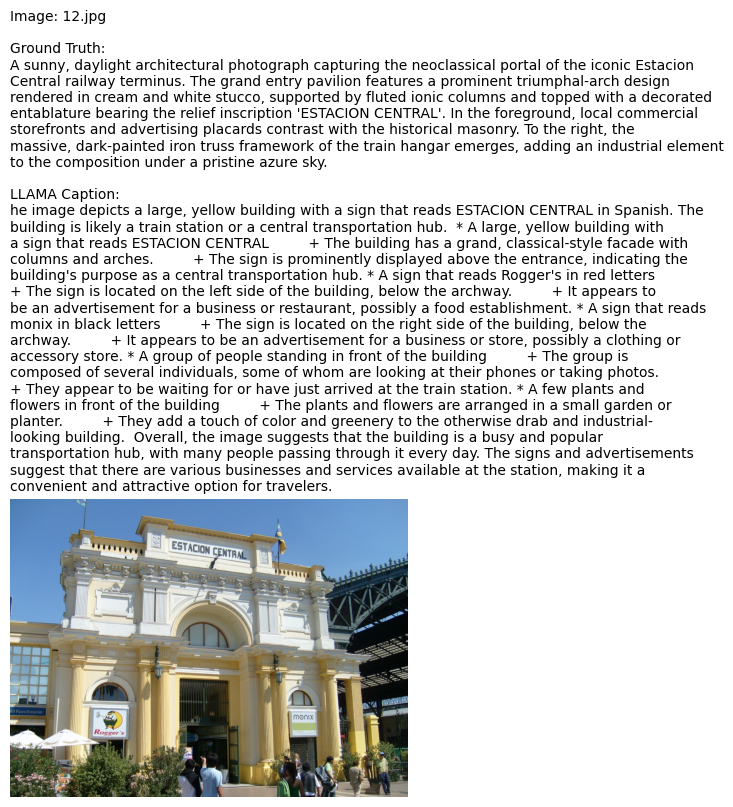

In [ ]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Rutas
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"
EXCEL_PATH = "/content/resultados_llama final.xlsx"

# Cargar tabla
df3 = pd.read_excel(EXCEL_PATH)


def plot_image_with_captions(df,index,prompt_id,model_name,image_dir=IMAGE_DIR, wrap_width=100):
    """
    index: índice de la fila en el DataFrame
    prompt_id: 1, 2 o 3
    model_name: por ejemplo "llama", "qwen" o "smolvlm"
    """

    row = df.iloc[index]

    file_name = row["file_name"]
    image_path = os.path.join(image_dir, file_name)

    manual_col = f"manual_description_{prompt_id}"
    model_col = f"{model_name}_prompt{prompt_id}"

    manual_caption = str(row[manual_col]).replace('"', '').strip()
    model_caption = str(row[model_col]).replace('"', '').strip()

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Image: {file_name}\n\n"
        f"Ground Truth:\n{textwrap.fill(manual_caption, wrap_width)}\n\n"
        f"{model_name.upper()} Caption:\n{textwrap.fill(model_caption, wrap_width)}"
    )

    plt.title(title, fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()



plot_image_with_captions(df3, index=11, prompt_id=3, model_name="llama")

# OCR

In [ ]:
#Cargamos Data frame con las imagenes de OCR:
import pandas as pd

df4 =pd.read_excel("descripciones_OCR.xlsx")
df4["llama_prompt1"] = ""
df4["llama_prompt2"] = ""
df4["llama_prompt3"] = ""
df4.head()

,file_name,prompt_1,prompt_2,prompt_3,llama_prompt1,llama_prompt2,llama_prompt3
0,20220101_035959.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
1,20230214_122422.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
2,20230430_150424.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
3,20230511_133754.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
4,20230811_151805.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,


In [ ]:
# Definimos una funcion auxiliar para hacer los captions:

import ollama

def generate_caption_llama(image_path, prompt_text):

    response = ollama.chat(
        model='llama3.2-vision',
        messages=[
            {
                'role': 'user',
                'content': prompt_text,
                'images': [image_path]
            }
        ]
    )

    caption = response['message']['content'].strip()

    return caption

In [ ]:
# Iteramos sobre las 20 imagenes:
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/OCR"

import os

for idx, row in df4.iterrows():

    try:

        image_path = os.path.join(IMAGE_DIR,row["file_name"])
        print(f"[{idx+1}/{len(df4)}] Procesando {row['file_name']}")
        df4.loc[idx, "llama_prompt1"] = generate_caption_llama(image_path,row["prompt_1"])


        # Guardado de seguridad
        df4.to_excel("/content/drive/MyDrive/Lab_inteligencia/resultados_llama_OCR.xlsx", index=False)

        print("Completado")

    except Exception as e:

        print(f" Error en {row['file_name']}: {e}")

        df4.to_excel("/content/drive/MyDrive/Lab_inteligencia/resultados_OCR.xlsx", index=False)

[1/15] Procesando 20220101_035959.jpg
Completado
[2/15] Procesando 20230214_122422.jpg
Completado
[3/15] Procesando 20230430_150424.jpg
Completado
[4/15] Procesando 20230511_133754.jpg
Completado
[5/15] Procesando 20230811_151805.jpg
Completado
[6/15] Procesando 20231108_090334.jpg
Completado
[7/15] Procesando 20240401_124930.jpg
Completado
[8/15] Procesando 20240603_120302.jpg
Completado
[9/15] Procesando 20250331_130243.jpg
Completado
[10/15] Procesando 20250819_074858.jpg
Completado
[11/15] Procesando 20250819_074905.jpg
Completado
[12/15] Procesando 20250908_140611.jpg
Completado
[13/15] Procesando 20250908_154959.jpg
Completado
[14/15] Procesando 20250908_155938.jpg


KeyboardInterrupt: 

In [ ]:
#Caragamos data frame con las descripciones generadas:

df_ocr = pd.read_excel("/content/drive/MyDrive/Lab_inteligencia/resultados_llama_OCR.xlsx")
df_ocr.head()

,file_name,prompt_1,prompt_2,prompt_3,llama_prompt1,llama_prompt2,llama_prompt3
0,20220101_035959.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image depicts a blue sign with white text,...",NaN,NaN
1,20230214_122422.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image shows a large, off-white building wi...",NaN,NaN
2,20230430_150424.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image features a sign on a table, displayi...",NaN,NaN
3,20230511_133754.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image shows a wall with two plaques on it,...",NaN,NaN
4,20230811_151805.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image appears to be a wall display of a mu...,NaN,NaN


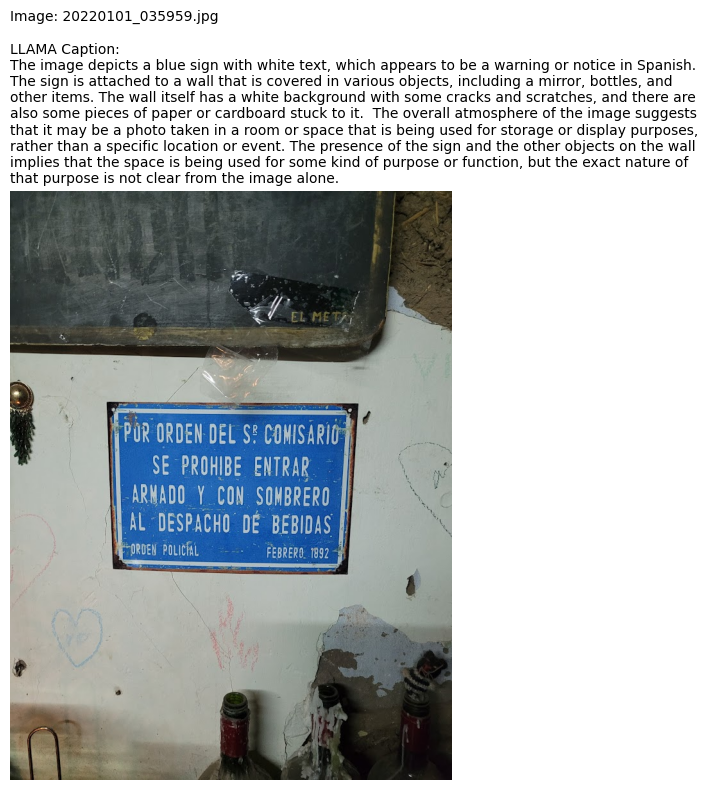

In [ ]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Rutas
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/OCR"


def plot_image_with_captions(df,index,prompt_id,model_name,image_dir=IMAGE_DIR, wrap_width=100):
    """
    index: índice de la fila en el DataFrame
    prompt_id: 1, 2 o 3
    model_name: por ejemplo "llama", "qwen" o "smolvlm"
    """

    row = df.iloc[index]

    file_name = row["file_name"]
    image_path = os.path.join(image_dir, file_name)


    model_col = f"{model_name}_prompt{prompt_id}"
    model_caption = str(row[model_col]).replace('"', '').strip()

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Image: {file_name}\n\n"
        f"{model_name.upper()} Caption:\n{textwrap.fill(model_caption, wrap_width)}"
    )

    plt.title(title, fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()



plot_image_with_captions(df_ocr, index=0, prompt_id=1, model_name="llama")